In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
loan_data = pd.read_csv("data/fintech_loan_portfolio_250k.csv")

In [13]:
loan_data.head(2).T

,0,1
loan_id,4e9df265-4022-487c-ad8c-e64b3a198274,804df7e3-fe87-4683-9493-001073a0a055
customer_id,4912e484-4b1a-4294-9e1b-043fdc7a2ed9,86a18fb8-b3f6-409d-b7a9-c88df0711dfd
age,41,32
annual_income,40182.06,133775.13
credit_score,612,578
employment_length,10+yrs,<1yr
loan_amount,7641.39,12836.7
loan_purpose,Education,Home Improvement
interest_rate,21.58,21.38
term,36,36


In [14]:
loan_data.shape

(250000, 17)

In [15]:
loan_data.dtypes

loan_id                 object
customer_id             object
age                      int64
annual_income          float64
credit_score             int64
employment_length       object
loan_amount            float64
loan_purpose            object
interest_rate          float64
term                     int64
dti_ratio              float64
home_ownership          object
monthly_installment    float64
loan_status             object
issue_date              object
state                   object
region                  object
dtype: object

In [16]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   loan_id              250000 non-null  object 
 1   customer_id          250000 non-null  object 
 2   age                  250000 non-null  int64  
 3   annual_income        250000 non-null  float64
 4   credit_score         250000 non-null  int64  
 5   employment_length    250000 non-null  object 
 6   loan_amount          250000 non-null  float64
 7   loan_purpose         250000 non-null  object 
 8   interest_rate        250000 non-null  float64
 9   term                 250000 non-null  int64  
 10  dti_ratio            250000 non-null  float64
 11  home_ownership       250000 non-null  object 
 12  monthly_installment  250000 non-null  float64
 13  loan_status          250000 non-null  object 
 14  issue_date           250000 non-null  object 
 15  state            

In [17]:
loan_data.nunique()

loan_id                250000
customer_id            250000
age                        55
annual_income          245191
credit_score              539
employment_length           5
loan_amount            227072
loan_purpose                5
interest_rate            2954
term                        2
dti_ratio                 501
home_ownership              3
monthly_installment     89225
loan_status                 4
issue_date                730
state                      28
region                      4
dtype: int64

In [19]:
loan_data.describe()

,age,annual_income,credit_score,loan_amount,interest_rate,term,dti_ratio,monthly_installment
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,37.827288,78397.239307,670.250348,14312.396758,16.962342,46.763328,0.521639,444.638341
std,10.365333,47609.726964,92.893423,9841.678199,5.410001,11.936131,0.119285,326.226341
min,21.000000,18000.000000,300.000000,1000.000000,5.000000,36.000000,0.100000,19.670000
25%,30.000000,45902.290000,607.000000,6958.767500,13.150000,36.000000,0.455000,205.020000
50%,38.000000,66934.345000,671.000000,11447.025000,16.910000,36.000000,0.600000,348.100000
75%,45.000000,97709.687500,736.000000,18902.982500,20.650000,60.000000,0.600000,588.102500
max,75.000000,600000.000000,850.000000,40000.000000,35.000000,60.000000,0.600000,1809.440000


In [26]:
bins = [21, 30, 40, 50, 60, 75] 
labels = ['21-30', '31-40', '41-50', '51-60', '61-75']

loan_data['age_group'] = pd.cut(loan_data['age'], bins=bins, labels=labels, include_lowest=True)
    

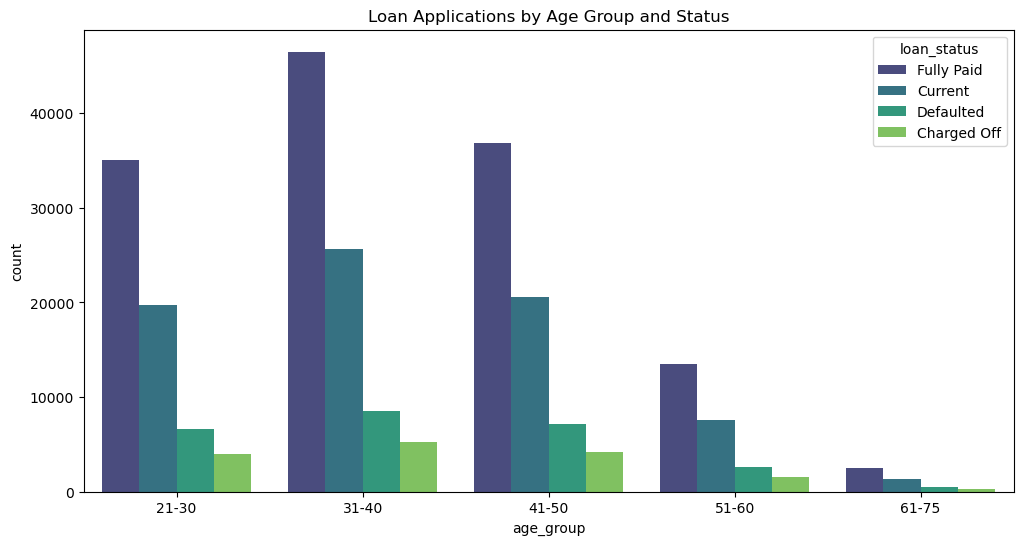

In [27]:
# what is the relationship between age and loan status
plt.figure(figsize=(12, 6))
sns.countplot(data=loan_data, x='age_group', hue='loan_status', palette='viridis')
plt.title('Loan Applications by Age Group and Status')
plt.show()

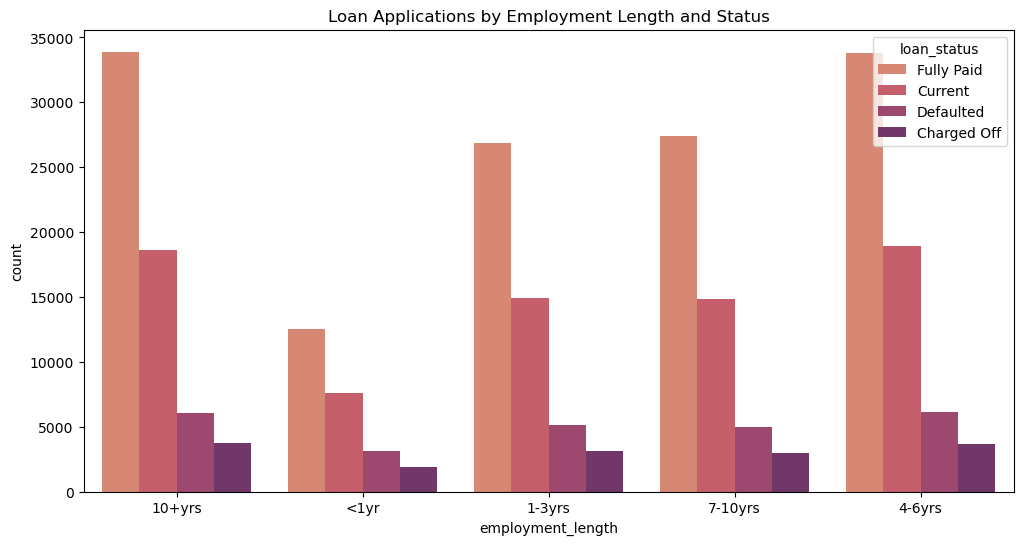

In [32]:
plt.figure(figsize=(12, 6))
sns.countplot(data=loan_data, x='employment_length', hue='loan_status', palette="flare")
plt.title('Loan Applications by Employment Length and Status')
plt.show()

In [30]:
bins = [0, 1000, 10000, 25000, 40000, np.inf]
labels = ['Low', 'Medium', 'High', 'Very High', 'Out of Range']

loan_data['loan_group'] = pd.cut(loan_data['loan_amount'], bins=bins, labels=labels, include_lowest=True)
    

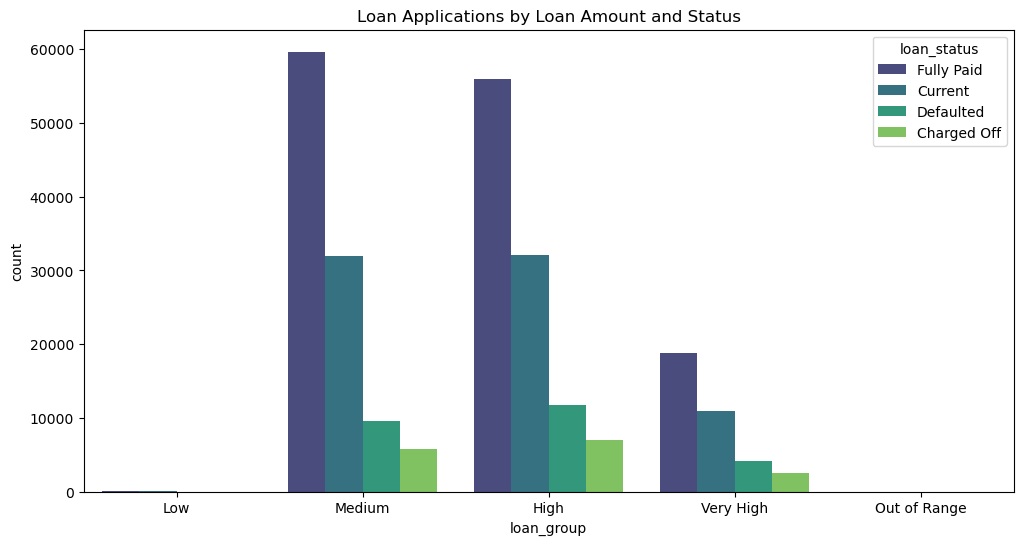

In [31]:
plt.figure(figsize=(12, 6))
sns.countplot(data=loan_data, x='loan_group', hue='loan_status', palette='viridis')
plt.title('Loan Applications by Loan Amount and Status')
plt.show()

## Distribution and health check

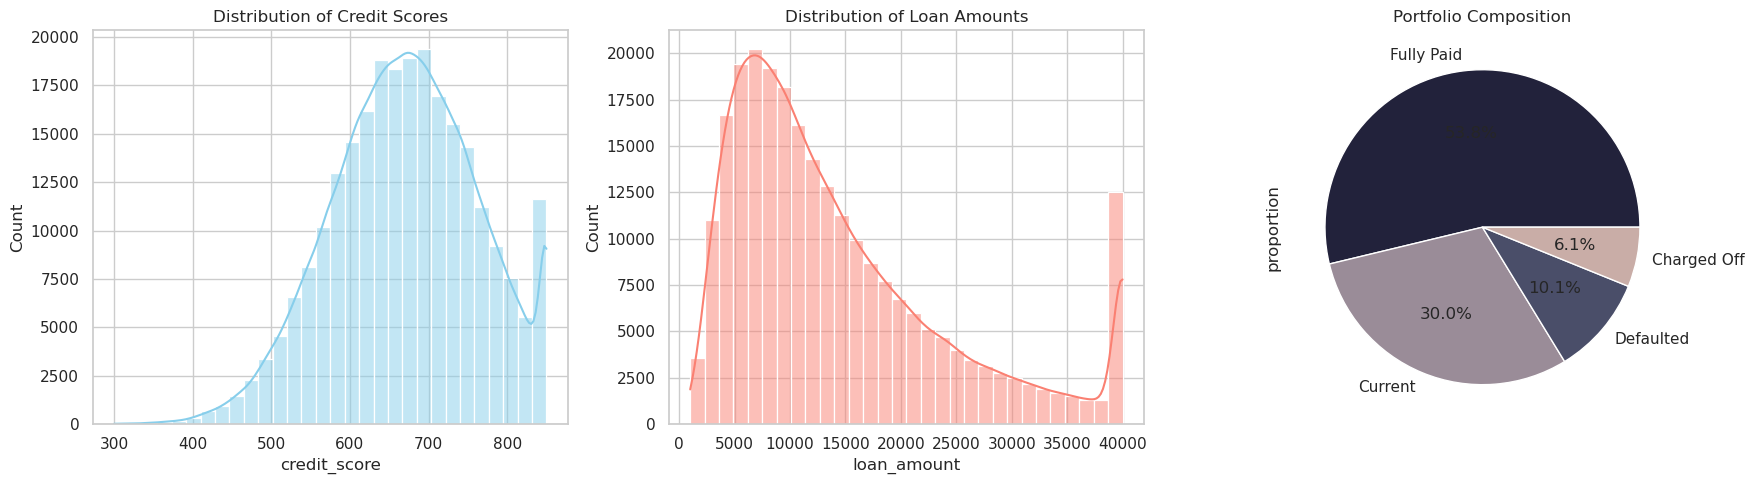

In [34]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.histplot(loan_data['credit_score'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Credit Scores')

sns.histplot(loan_data['loan_amount'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Loan Amounts')

loan_data['loan_status'].value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%', ax=axes[2], colors=['#22223b','#9a8c98','#4a4e69','#c9ada7'])
axes[2].set_title('Portfolio Composition')

plt.tight_layout()
plt.show()

## Risk Correlation

/tmp/ipykernel_249597/2119170459.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='score_range', y='interest_rate', data=loan_data, palette='viridis')


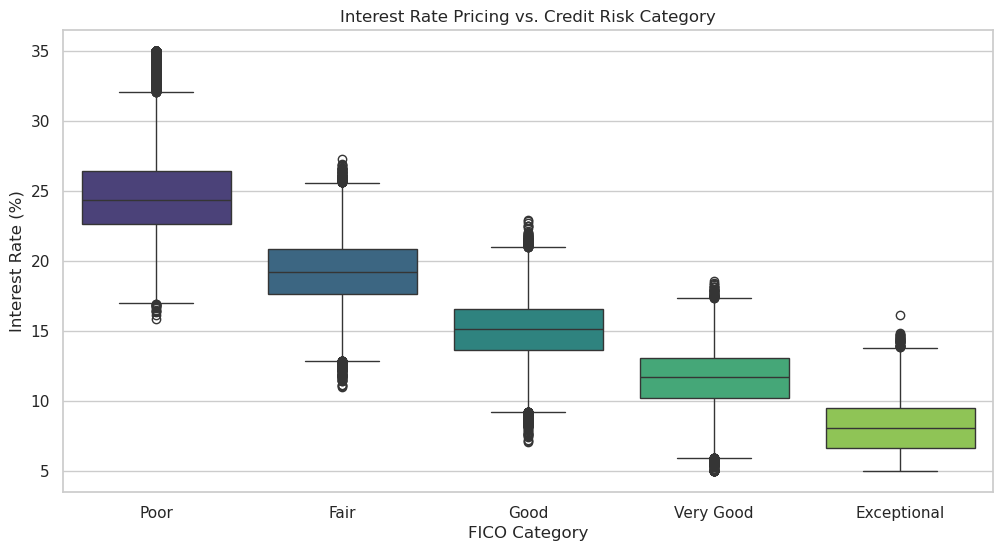

In [35]:
bins=[300, 580, 670, 740, 800, 850]
labels=['Poor', 'Fair', 'Good', 'Very Good', 'Exceptional']

loan_data['score_range'] = pd.cut(
    loan_data['credit_score'], 
    bins = bins,
    labels = labels
)

plt.figure(figsize=(12,6))
sns.boxplot(x='score_range', y='interest_rate', data=loan_data, palette='viridis')
plt.title('Interest Rate Pricing vs. Credit Risk Category')
plt.ylabel('Interest Rate (%)')
plt.xlabel('FICO Category')
plt.show()

## Trend Analysis (Time-Series)

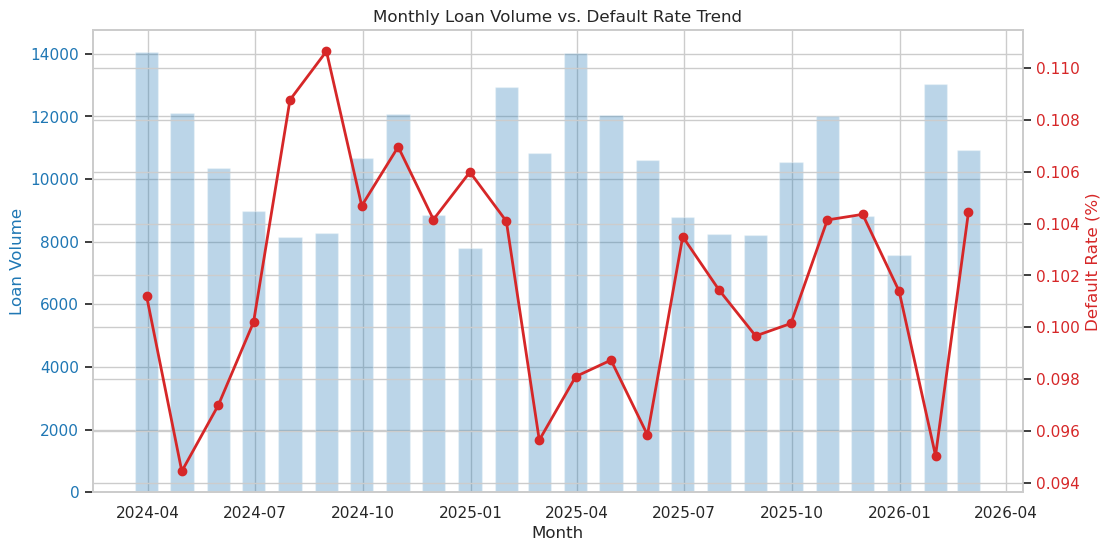

In [38]:
loan_data['is_default'] = loan_data['loan_status'].apply(lambda x: 1 if x == 'Defaulted' else 0)
# convery  date to datetime and set as index
loan_data['issue_date'] = pd.to_datetime(loan_data['issue_date'])
loan_trend = loan_data.set_index('issue_date')

# resample by month to see volume vs. Average Interest Rate
monthly_trends = loan_trend.resample('M').agg({
    'loan_id': 'count',
    'interest_rate': 'mean',
    'is_default': 'mean'
})

fig, ax1 = plt.subplots(figsize=(12, 6))

# plot volume
ax1.set_xlabel('Month')
ax1.set_ylabel('Loan Volume', color='tab:blue')
ax1.bar(monthly_trends.index, monthly_trends['loan_id'], color='tab:blue', alpha=0.3, width=20, label='Volume')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Plot Default Rate Trend
ax2 = ax1.twinx()
ax2.set_ylabel('Default Rate (%)', color='tab:red')
ax2.plot(monthly_trends.index, monthly_trends['is_default'], color='tab:red', marker='o', linewidth=2, label='Default Rate')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Monthly Loan Volume vs. Default Rate Trend')
plt.show()

 ## what is our least and most  profittable segments

In [39]:
# Calculate simple 'Expected Yield'
# Yield = Interest Rate - (Default Rate * 100)
segment_analysis = loan_data.groupby('score_range').agg({
    'interest_rate': 'mean',
    'is_default': 'mean',
    'loan_amount': 'sum'
}).reset_index()

segment_analysis['expected_yield'] = segment_analysis['interest_rate'] - (segment_analysis['is_default'] * 100)

print(segment_analysis[['score_range', 'interest_rate', 'is_default', 'expected_yield']])

   score_range  interest_rate  is_default  expected_yield
0         Poor      24.688170    0.192970        5.391158
1         Fair      19.236373    0.110420        8.194370
2         Good      15.105981    0.065958        8.510189
3    Very Good      11.635062    0.062527        5.382332
4  Exceptional       8.136701    0.063213        1.815383


/tmp/ipykernel_249597/1418598848.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_analysis = loan_data.groupby('score_range').agg({


## Loan to income ratio

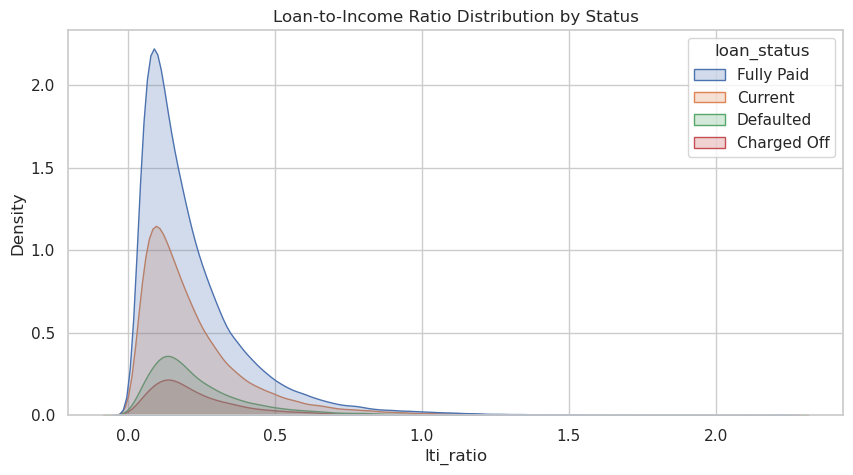

In [41]:
loan_data['lti_ratio'] = loan_data['loan_amount'] / loan_data['annual_income']

plt.figure(figsize=(10, 5))
sns.kdeplot(data=loan_data, x="lti_ratio", hue="loan_status", fill=True)
plt.title("Loan-to-Income Ratio Distribution by Status")
plt.show()

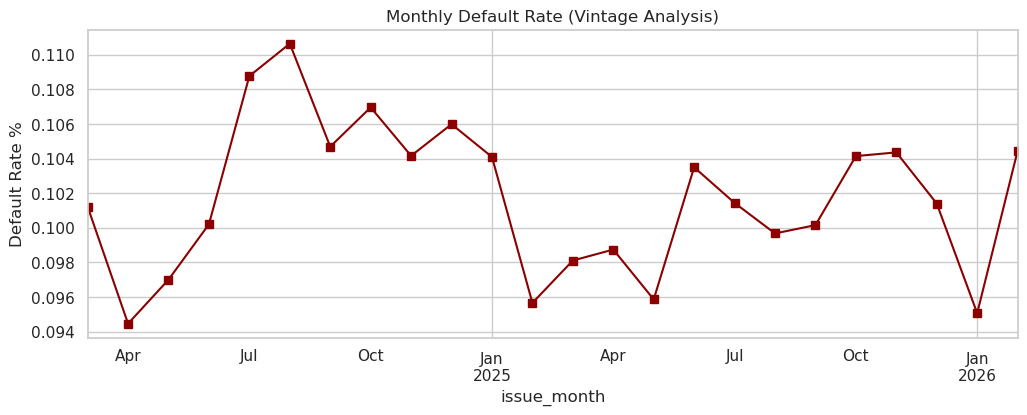

In [43]:
loan_data['issue_month'] = loan_data['issue_date'].dt.to_period('M')
vintage_perf = loan_data.groupby('issue_month')['is_default'].mean()

plt.figure(figsize=(12, 4))
vintage_perf.plot(color='darkred', marker='s')
plt.title('Monthly Default Rate (Vintage Analysis)')
plt.ylabel('Default Rate %')
plt.show()